# Flight Price Prediction(EDA + Feature Engineering)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
train_df = pd.read_excel('Data_Train.xlsx')
train_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
test_df = pd.read_excel('Test_set.xlsx')
test_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


In [4]:
final_df = pd.concat([train_df,test_df],ignore_index=True)
final_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0


In [5]:
final_df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
13349,Air India,6/06/2019,Kolkata,Banglore,CCU → DEL → BLR,20:30,20:25 07 Jun,23h 55m,1 stop,No info,NaN
13350,IndiGo,27/03/2019,Kolkata,Banglore,CCU → BLR,14:20,16:55,2h 35m,non-stop,No info,NaN
13351,Jet Airways,6/03/2019,Delhi,Cochin,DEL → BOM → COK,21:50,04:25 07 Mar,6h 35m,1 stop,No info,NaN
13352,Air India,6/03/2019,Delhi,Cochin,DEL → BOM → COK,04:00,19:15,15h 15m,1 stop,No info,NaN
13353,Multiple carriers,15/06/2019,Delhi,Cochin,DEL → BOM → COK,04:55,19:15,14h 20m,1 stop,No info,NaN


In [6]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Date_of_Journey  13354 non-null  object 
 2   Source           13354 non-null  object 
 3   Destination      13354 non-null  object 
 4   Route            13353 non-null  object 
 5   Dep_Time         13354 non-null  object 
 6   Arrival_Time     13354 non-null  object 
 7   Duration         13354 non-null  object 
 8   Total_Stops      13353 non-null  object 
 9   Additional_Info  13354 non-null  object 
 10  Price            10683 non-null  float64
dtypes: float64(1), object(10)
memory usage: 1.1+ MB


In [7]:
final_df['Date']= final_df['Date_of_Journey'].str.split('/').str[0]
final_df['Month']=final_df['Date_of_Journey'].str.split('/').str[1]
final_df['Year']=final_df['Date_of_Journey'].str.split('/').str[2]

In [8]:
final_df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0,24,03,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,1,05,2019


In [9]:
final_df['Date']=final_df['Date'].astype(int)
final_df['Month']=final_df['Month'].astype(int)
final_df['Year']=final_df['Year'].astype(int)

In [10]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Date_of_Journey  13354 non-null  object 
 2   Source           13354 non-null  object 
 3   Destination      13354 non-null  object 
 4   Route            13353 non-null  object 
 5   Dep_Time         13354 non-null  object 
 6   Arrival_Time     13354 non-null  object 
 7   Duration         13354 non-null  object 
 8   Total_Stops      13353 non-null  object 
 9   Additional_Info  13354 non-null  object 
 10  Price            10683 non-null  float64
 11  Date             13354 non-null  int32  
 12  Month            13354 non-null  int32  
 13  Year             13354 non-null  int32  
dtypes: float64(1), int32(3), object(10)
memory usage: 1.3+ MB


In [11]:
final_df.drop('Date_of_Journey',axis=1,inplace=True)

In [12]:
final_df.head(1)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0,24,3,2019


In [13]:
# final_df['Arrival_Time'].str.split(' ').str[0]
final_df['Arrival_Time'] = final_df['Arrival_Time'].apply(lambda x : x.split(' ')[0])

In [14]:
final_df['Arrival_hour'] = final_df['Arrival_Time'].str.split(':').str[0]
final_df['Arrival_min'] = final_df['Arrival_Time'].str.split(':').str[1]

In [15]:
final_df['Arrival_hour']=final_df['Arrival_hour'].astype(int)
final_df['Arrival_min']=final_df['Arrival_min'].astype(int)

In [16]:
final_df.drop('Arrival_Time',axis=1,inplace=True)

In [17]:
final_df['Dept_hour'] = final_df['Dep_Time'].str.split(':').str[0]
final_df['Dept_min'] = final_df['Dep_Time'].str.split(':').str[1]
final_df['Dept_hour']=final_df['Dept_hour'].astype(int)
final_df['Dept_min']=final_df['Dept_min'].astype(int)
final_df.drop('Dep_Time',axis=1,inplace=True)

In [18]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Source           13354 non-null  object 
 2   Destination      13354 non-null  object 
 3   Route            13353 non-null  object 
 4   Duration         13354 non-null  object 
 5   Total_Stops      13353 non-null  object 
 6   Additional_Info  13354 non-null  object 
 7   Price            10683 non-null  float64
 8   Date             13354 non-null  int32  
 9   Month            13354 non-null  int32  
 10  Year             13354 non-null  int32  
 11  Arrival_hour     13354 non-null  int32  
 12  Arrival_min      13354 non-null  int32  
 13  Dept_hour        13354 non-null  int32  
 14  Dept_min         13354 non-null  int32  
dtypes: float64(1), int32(7), object(7)
memory usage: 1.2+ MB


In [19]:
final_df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [20]:
final_df['Total_Stops'] = final_df['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4,'nan':1})

In [21]:
final_df.drop('Route',axis=1,inplace=True)

In [22]:
final_df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
0,IndiGo,Banglore,New Delhi,2h 50m,0.0,No info,3897.0,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,7h 25m,2.0,No info,7662.0,1,5,2019,13,15,5,50
2,Jet Airways,Delhi,Cochin,19h,2.0,No info,13882.0,9,6,2019,4,25,9,25
3,IndiGo,Kolkata,Banglore,5h 25m,1.0,No info,6218.0,12,5,2019,23,30,18,5
4,IndiGo,Banglore,New Delhi,4h 45m,1.0,No info,13302.0,1,3,2019,21,35,16,50


In [23]:
final_df['Additional_Info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [24]:
final_df['duration_hour']=final_df['Duration'].str.split(' ').str[0].str.split('h').str[0]

In [25]:
final_df[final_df['duration_hour']=='5m']

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_hour
6474,Air India,Mumbai,Hyderabad,5m,2.0,No info,17327.0,6,3,2019,16,55,16,50,5m
13343,Air India,Mumbai,Hyderabad,5m,2.0,No info,NaN,12,3,2019,16,55,16,50,5m


In [26]:
final_df.drop(6474,axis=0,inplace=True)
final_df.drop(13343,axis=0,inplace=True)

In [27]:
final_df[final_df['duration_hour']=='5m']

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_hour


In [28]:
final_df['duration_hour'] = final_df['duration_hour'].astype(int)

In [29]:
final_df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_hour
0,IndiGo,Banglore,New Delhi,2h 50m,0.0,No info,3897.0,24,3,2019,1,10,22,20,2
1,Air India,Kolkata,Banglore,7h 25m,2.0,No info,7662.0,1,5,2019,13,15,5,50,7
2,Jet Airways,Delhi,Cochin,19h,2.0,No info,13882.0,9,6,2019,4,25,9,25,19
3,IndiGo,Kolkata,Banglore,5h 25m,1.0,No info,6218.0,12,5,2019,23,30,18,5,5
4,IndiGo,Banglore,New Delhi,4h 45m,1.0,No info,13302.0,1,3,2019,21,35,16,50,4


In [30]:
final_df['duration_hour'] = final_df['duration_hour']*60

In [31]:
final_df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_hour
0,IndiGo,Banglore,New Delhi,2h 50m,0.0,No info,3897.0,24,3,2019,1,10,22,20,120
1,Air India,Kolkata,Banglore,7h 25m,2.0,No info,7662.0,1,5,2019,13,15,5,50,420
2,Jet Airways,Delhi,Cochin,19h,2.0,No info,13882.0,9,6,2019,4,25,9,25,1140
3,IndiGo,Kolkata,Banglore,5h 25m,1.0,No info,6218.0,12,5,2019,23,30,18,5,300
4,IndiGo,Banglore,New Delhi,4h 45m,1.0,No info,13302.0,1,3,2019,21,35,16,50,240


In [32]:
final_df['duration_min']=final_df['Duration'].str.split(' ').str[1].str.split('m').str[0]

In [33]:
final_df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_hour,duration_min
0,IndiGo,Banglore,New Delhi,2h 50m,0.0,No info,3897.0,24,3,2019,1,10,22,20,120,50
1,Air India,Kolkata,Banglore,7h 25m,2.0,No info,7662.0,1,5,2019,13,15,5,50,420,25
2,Jet Airways,Delhi,Cochin,19h,2.0,No info,13882.0,9,6,2019,4,25,9,25,1140,NaN
3,IndiGo,Kolkata,Banglore,5h 25m,1.0,No info,6218.0,12,5,2019,23,30,18,5,300,25
4,IndiGo,Banglore,New Delhi,4h 45m,1.0,No info,13302.0,1,3,2019,21,35,16,50,240,45


In [34]:
final_df['duration_min'] = final_df['duration_min'].fillna(0)

In [35]:
final_df['duration_min'] = final_df['duration_min'].astype(int)

In [36]:
final_df['duration_min'] = final_df['duration_min'] + final_df['duration_hour']

In [37]:
final_df.drop('duration_hour',axis=1,inplace=True)

In [38]:
final_df.drop('Duration',axis=1,inplace=True)

In [39]:
final_df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_min
0,IndiGo,Banglore,New Delhi,0.0,No info,3897.0,24,3,2019,1,10,22,20,170
1,Air India,Kolkata,Banglore,2.0,No info,7662.0,1,5,2019,13,15,5,50,445
2,Jet Airways,Delhi,Cochin,2.0,No info,13882.0,9,6,2019,4,25,9,25,1140
3,IndiGo,Kolkata,Banglore,1.0,No info,6218.0,12,5,2019,23,30,18,5,325
4,IndiGo,Banglore,New Delhi,1.0,No info,13302.0,1,3,2019,21,35,16,50,285


In [40]:
final_df['Airline'].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [41]:
from sklearn.preprocessing import LabelEncoder
# Create separate LabelEncoder instances for each column
# labelencoder = LabelEncoder()
labelencoder_airline = LabelEncoder()
labelencoder_source = LabelEncoder()
labelencoder_destination = LabelEncoder()
labelencoder_additional_info = LabelEncoder()

In [42]:
# Fit and transform each column
final_df['Airline'] = labelencoder_airline.fit_transform(final_df['Airline'])

In [43]:
final_df['Source'] = labelencoder_source.fit_transform(final_df['Source'])

In [44]:
final_df['Destination'] = labelencoder_destination.fit_transform(final_df['Destination'])

In [45]:
final_df['Additional_Info'] = labelencoder_additional_info.fit_transform(final_df['Additional_Info'])

In [46]:
final_df.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_min
0,3,0,5,0.0,8,3897.0,24,3,2019,1,10,22,20,170
1,1,3,0,2.0,8,7662.0,1,5,2019,13,15,5,50,445


In [47]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13352 entries, 0 to 13353
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13352 non-null  int32  
 1   Source           13352 non-null  int32  
 2   Destination      13352 non-null  int32  
 3   Total_Stops      13351 non-null  float64
 4   Additional_Info  13352 non-null  int32  
 5   Price            10682 non-null  float64
 6   Date             13352 non-null  int32  
 7   Month            13352 non-null  int32  
 8   Year             13352 non-null  int32  
 9   Arrival_hour     13352 non-null  int32  
 10  Arrival_min      13352 non-null  int32  
 11  Dept_hour        13352 non-null  int32  
 12  Dept_min         13352 non-null  int32  
 13  duration_min     13352 non-null  int32  
dtypes: float64(2), int32(12)
memory usage: 938.8 KB


In [48]:
final_df.isnull().sum()

Airline               0
Source                0
Destination           0
Total_Stops           1
Additional_Info       0
Price              2670
Date                  0
Month                 0
Year                  0
Arrival_hour          0
Arrival_min           0
Dept_hour             0
Dept_min              0
duration_min          0
dtype: int64

In [49]:
final_df[final_df['Total_Stops'].isnull()]
# 9039 row have NaN , we change with 1 value

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_min
9039,1,2,1,NaN,8,7480.0,6,5,2019,9,25,9,45,1420


In [50]:
final_df['Total_Stops'] = final_df['Total_Stops'].fillna(1)

In [51]:
final_df[final_df['Total_Stops'].isnull()]

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_min


In [57]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13352 entries, 0 to 13353
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13352 non-null  int32  
 1   Source           13352 non-null  int32  
 2   Destination      13352 non-null  int32  
 3   Total_Stops      13352 non-null  float64
 4   Additional_Info  13352 non-null  int32  
 5   Price            10682 non-null  float64
 6   Date             13352 non-null  int32  
 7   Month            13352 non-null  int32  
 8   Year             13352 non-null  int32  
 9   Arrival_hour     13352 non-null  int32  
 10  Arrival_min      13352 non-null  int32  
 11  Dept_hour        13352 non-null  int32  
 12  Dept_min         13352 non-null  int32  
 13  duration_min     13352 non-null  int32  
dtypes: float64(2), int32(12)
memory usage: 938.8 KB


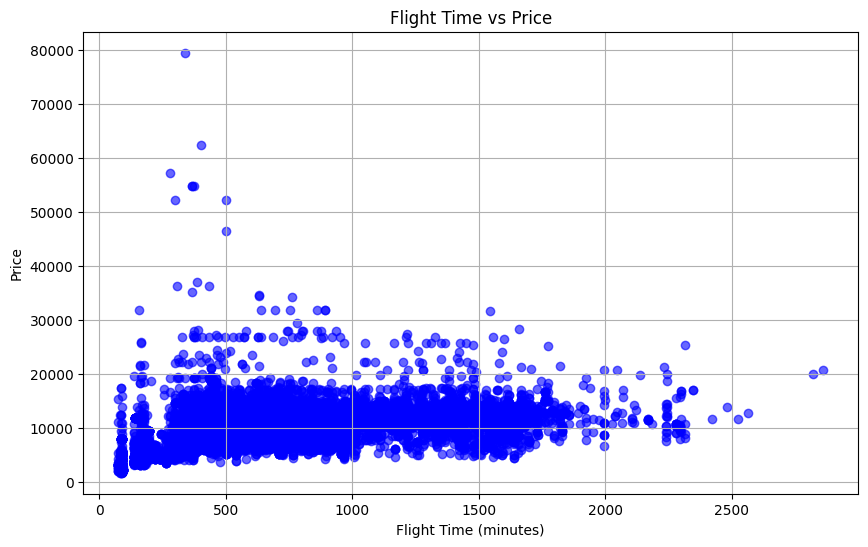

In [62]:
# duration_min vs price
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(final_df['duration_min'], final_df['Price'], color='blue', alpha=0.6)
plt.title('Flight Time vs Price')
plt.xlabel('Flight Time (minutes)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

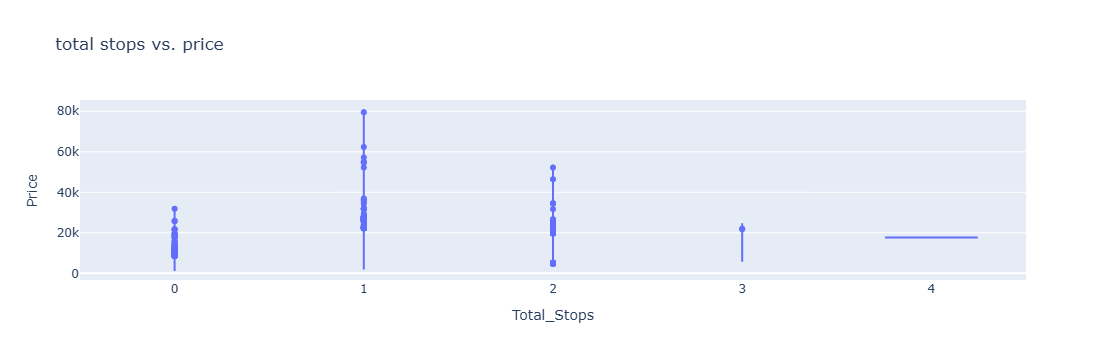

In [65]:
import plotly.express as px
px.violin(final_df,x="Total_Stops",y="Price",title='total stops vs. price')

In [52]:
# Create dictionaries to map original values to encoded values for each column
mapping_airline = dict(zip(labelencoder_airline.classes_, labelencoder_airline.transform(labelencoder_airline.classes_)))
mapping_source = dict(zip(labelencoder_source.classes_, labelencoder_source.transform(labelencoder_source.classes_)))
mapping_destination = dict(zip(labelencoder_destination.classes_, labelencoder_destination.transform(labelencoder_destination.classes_)))
mapping_additional_info = dict(zip(labelencoder_additional_info.classes_, labelencoder_additional_info.transform(labelencoder_additional_info.classes_)))

In [53]:
print("Airline mapping:")
for key, value in mapping_airline.items():
    print(f"'{key}': {value}")

Airline mapping:
'Air Asia': 0
'Air India': 1
'GoAir': 2
'IndiGo': 3
'Jet Airways': 4
'Jet Airways Business': 5
'Multiple carriers': 6
'Multiple carriers Premium economy': 7
'SpiceJet': 8
'Trujet': 9
'Vistara': 10
'Vistara Premium economy': 11


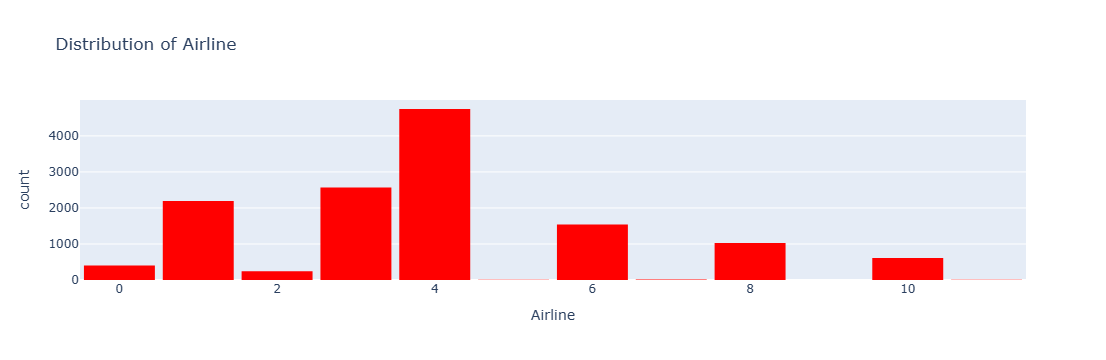

In [77]:
fig = px.histogram(final_df,
                   x="Airline",
                   # marginal="box",
                   color_discrete_sequence=["red"],
                   title="Distribution of Airline")
fig.update_layout(bargap=0.1)
fig.show()

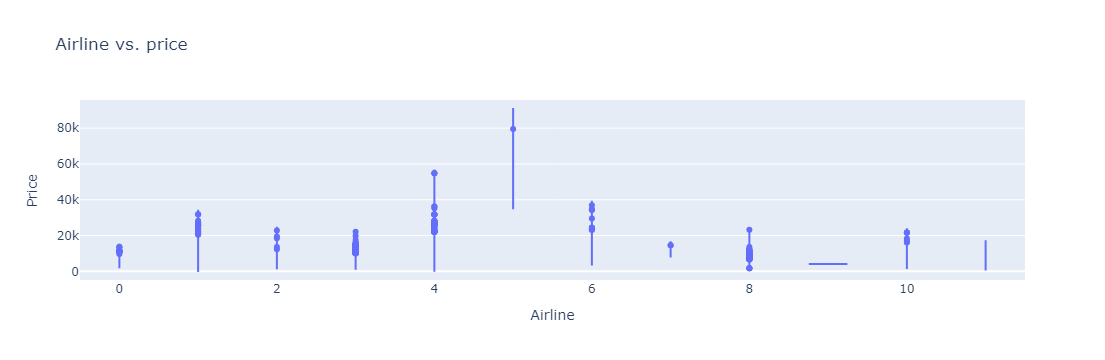

In [79]:
px.violin(final_df,x="Airline",y="Price",title='Airline vs. price')

In [73]:
# now Source
print("\nSource mapping:")
for key, value in mapping_source.items():
    print(f"'{key}': {value}")


Source mapping:
'Banglore': 0
'Chennai': 1
'Delhi': 2
'Kolkata': 3
'Mumbai': 4


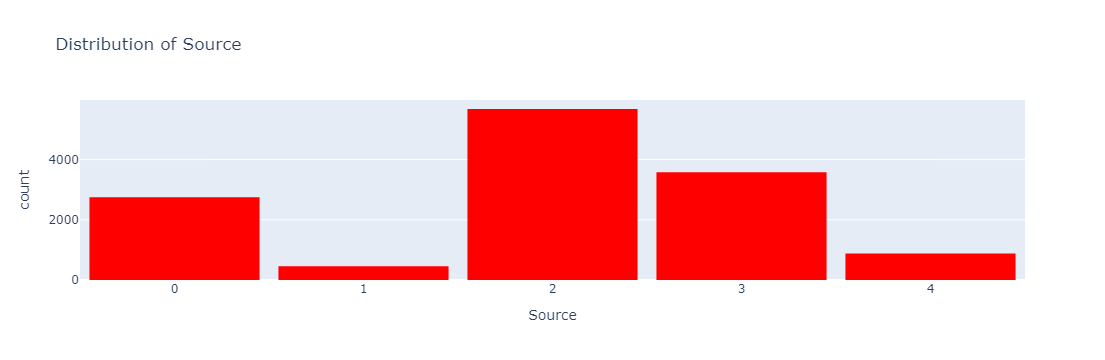

In [78]:
fig = px.histogram(final_df,
                   x="Source",
                   # marginal="box",
                   color_discrete_sequence=["red"],
                   title="Distribution of Source")
fig.update_layout(bargap=0.1)
fig.show()

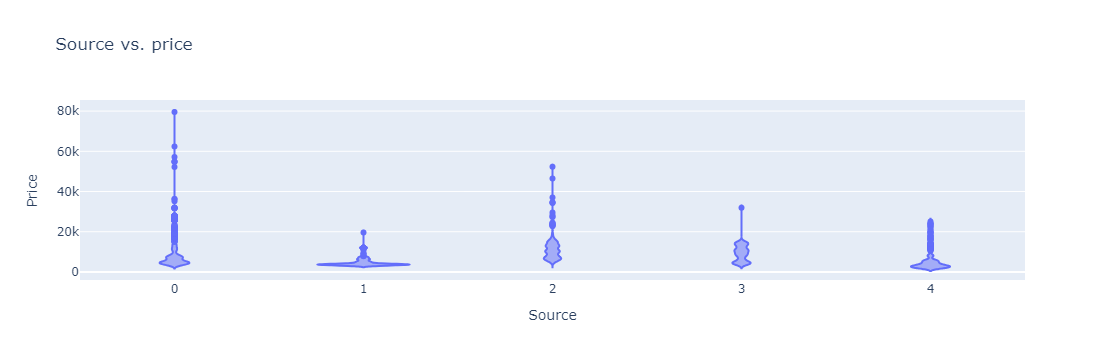

In [80]:
px.violin(final_df,x="Source",y="Price",title='Source vs. price')

In [55]:
print("\nDestination mapping:")
for key, value in mapping_destination.items():
    print(f"'{key}': {value}")


Destination mapping:
'Banglore': 0
'Cochin': 1
'Delhi': 2
'Hyderabad': 3
'Kolkata': 4
'New Delhi': 5


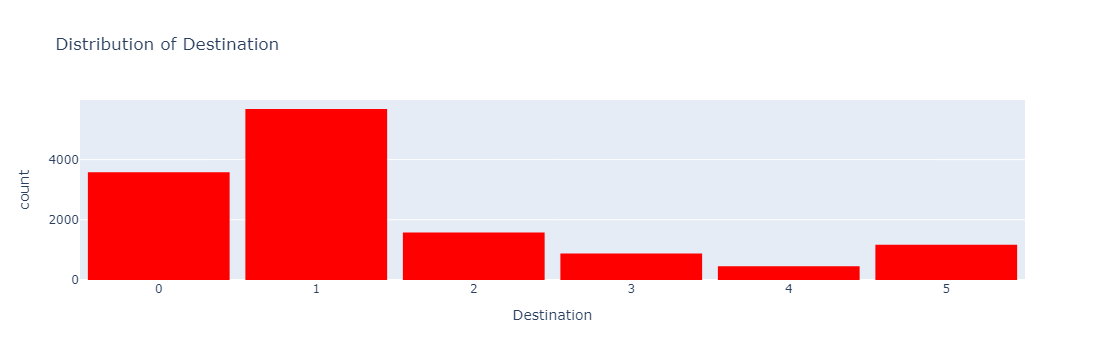

In [81]:
fig = px.histogram(final_df,
                   x="Destination",
                   # marginal="box",
                   color_discrete_sequence=["red"],
                   title="Distribution of Destination")
fig.update_layout(bargap=0.1)
fig.show()

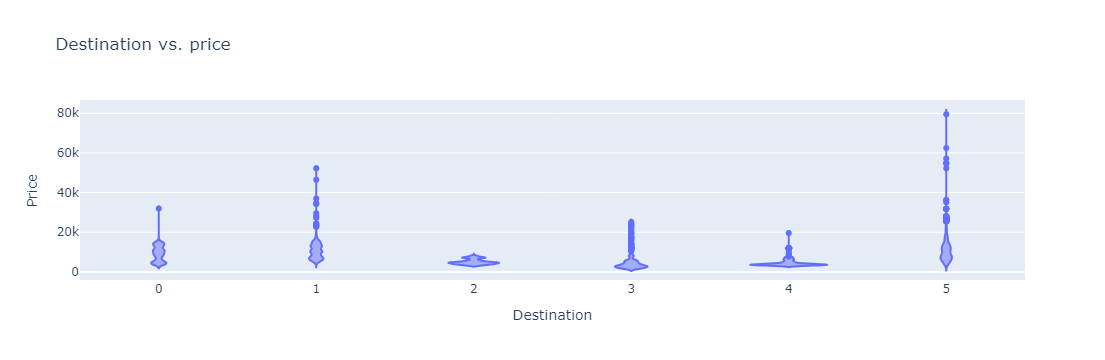

In [82]:
px.violin(final_df,x="Destination",y="Price",title='Destination vs. price')

In [56]:
print("\nAdditional Info mapping:")
for key, value in mapping_additional_info.items():
    print(f"'{key}': {value}")


Additional Info mapping:
'1 Long layover': 0
'1 Short layover': 1
'2 Long layover': 2
'Business class': 3
'Change airports': 4
'In-flight meal not included': 5
'No Info': 6
'No check-in baggage included': 7
'No info': 8
'Red-eye flight': 9


### feature scaling

In [84]:
df_test = final_df[final_df['Price'].isnull()]

In [86]:
df_train = final_df[~final_df['Price'].isnull()]

In [87]:
df_train

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_min
0,3,0,5,0.0,8,3897.0,24,3,2019,1,10,22,20,170
1,1,3,0,2.0,8,7662.0,1,5,2019,13,15,5,50,445
2,4,2,1,2.0,8,13882.0,9,6,2019,4,25,9,25,1140
3,3,3,0,1.0,8,6218.0,12,5,2019,23,30,18,5,325
4,3,0,5,1.0,8,13302.0,1,3,2019,21,35,16,50,285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,3,0,0.0,8,4107.0,9,4,2019,22,25,19,55,150
10679,1,3,0,0.0,8,4145.0,27,4,2019,23,20,20,45,155
10680,4,0,2,0.0,8,7229.0,27,4,2019,11,20,8,20,180
10681,10,0,5,0.0,8,12648.0,1,3,2019,14,10,11,30,160


In [88]:
df_test

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_min
10683,4,2,1,1.0,8,NaN,6,6,2019,4,25,17,30,655
10684,3,3,0,1.0,8,NaN,12,5,2019,10,20,6,20,240
10685,4,2,1,1.0,5,NaN,21,5,2019,19,0,19,15,1425
10686,6,2,1,1.0,8,NaN,21,5,2019,21,0,8,0,780
10687,0,0,2,0.0,8,NaN,24,6,2019,2,45,23,55,170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13349,1,3,0,1.0,8,NaN,6,6,2019,20,25,20,30,1435
13350,3,3,0,0.0,8,NaN,27,3,2019,16,55,14,20,155
13351,4,2,1,1.0,8,NaN,6,3,2019,4,25,21,50,395
13352,1,2,1,1.0,8,NaN,6,3,2019,19,15,4,0,915


In [89]:
X=df_train.drop('Price',axis=1)
X.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_min
0,3,0,5,0.0,8,24,3,2019,1,10,22,20,170
1,1,3,0,2.0,8,1,5,2019,13,15,5,50,445
2,4,2,1,2.0,8,9,6,2019,4,25,9,25,1140
3,3,3,0,1.0,8,12,5,2019,23,30,18,5,325
4,3,0,5,1.0,8,1,3,2019,21,35,16,50,285


In [90]:
y=df_train['Price']
y.head()

0     3897.0
1     7662.0
2    13882.0
3     6218.0
4    13302.0
Name: Price, dtype: float64

In [92]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.33, random_state=42)

In [93]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [94]:
from sklearn.linear_model import LinearRegression
## cross validation
from sklearn.model_selection import cross_val_score


In [95]:
regression = LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [96]:
mse = cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=10)

In [97]:
mse

array([-10099349.31158771,  -9833795.32162962, -16045412.31469285,
       -13813344.6671489 , -15883725.61712402, -14109405.63488086,
       -11574329.49623034, -12522259.89141514, -12209320.12926107,
       -10196121.55273889])

In [98]:
np.mean(mse)

-12628706.393670943

In [99]:
reg_pred= regression.predict(X_test)

In [100]:
reg_pred

array([13538.4518938 ,  9126.35092209, 11436.8429289 , ...,
       11089.08157342,  8878.0120119 ,  9901.20293024])

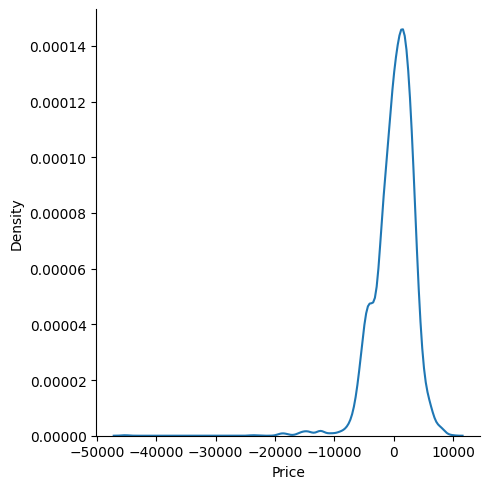

In [101]:
sns.displot(reg_pred - y_test , kind = 'kde')

In [102]:
from sklearn.metrics import r2_score
score = r2_score(reg_pred,y_test)

In [103]:
score

-0.1980550342368863

In [109]:
X_train

array([[-0.40417025,  0.05125594, -0.30136719, ..., -0.42987437,
         0.55898083,  0.49714076],
       [ 0.02241416,  0.05125594, -0.30136719, ..., -0.25574434,
        -1.30896231, -0.87867656],
       [ 0.87558297,  0.05125594, -0.30136719, ..., -0.95226443,
        -1.04211329, -0.1907679 ],
       ...,
       [ 0.87558297,  0.05125594, -0.30136719, ..., -0.08161432,
         1.35952789,  0.23180457],
       [-0.40417025, -1.6429126 ,  2.398581  , ..., -2.17117459,
         0.82582985, -0.93764016],
       [ 0.02241416,  1.74542448,  1.0486069 , ..., -0.42987437,
        -0.24156623, -1.08504916]])

In [110]:
X_test

array([[ 0.87558297,  0.05125594, -0.30136719, ...,  0.44077574,
        -1.04211329, -0.03353163],
       [-0.83075465,  0.05125594, -0.30136719, ..., -0.42987437,
         0.55898083, -0.20059517],
       [ 2.5819206 ,  0.89834021, -0.97635424, ...,  1.31142585,
        -0.24156623,  0.24163183],
       ...,
       [-0.40417025, -1.6429126 ,  2.398581  , ..., -1.12639445,
         0.02528279, -0.6624767 ],
       [ 0.87558297,  0.05125594, -0.30136719, ..., -0.42987437,
        -1.30896231,  0.56593163],
       [ 0.02241416,  0.89834021, -0.97635424, ...,  1.31142585,
         0.02528279,  0.86074963]])

In [111]:
y_test

6075    16655.0
3544     4959.0
9291     9187.0
5032     3858.0
2483    12898.0
         ...   
6148    14714.0
4680    17234.0
4337     8434.0
7290     7198.0
8642    11467.0
Name: Price, Length: 3526, dtype: float64

In [112]:
y_train

8455      5883.0
8424      7202.0
10179    10696.0
3880     10844.0
6176     12898.0
          ...   
5734     12242.0
5191     10844.0
5390      7670.0
860       6144.0
7271      5678.0
Name: Price, Length: 7156, dtype: float64